In [88]:
#  for downloading the dataset, you can use the kagglehub library, which provides a interface to download datasets from Kaggle. Here's how you can do it:
# import kagglehub

# path = kagglehub.dataset_download(
#     "cjinny/mrnet-v1",
#     output_dir="/Users/yaseenahmed/Documents/ML Project/MRNet-v1", # use youre own path here for where you want to save the dataset guys.
#     force_download=True   # important since folder might exist partially
# )

# print("Downloaded to:", path)

In [89]:
# import os

# DATA_ROOT = "/Users/yaseenahmed/Documents/ML Project/MRNet-v1/MRNet-v1.0" 
# USe your actual path to the dataset here guys.

# print("Exists:", os.path.exists(DATA_ROOT))
# print("Contents:", os.listdir(DATA_ROOT))

In [90]:
# pip install timm scikit-learn matplotlib seaborn pandas tqdm pillow torchvision

# run the above cell to install the required libraries.

In [91]:
import os
import glob
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import timm

In [92]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("runs/mrnet_experiment")

In [93]:
# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Paths
# -----------------------------
DATA_ROOT = "/Users/yaseenahmed/Downloads/MRNet-v1.0"      # use your actual path to the dataset here
OOD_ROOT = "/Users/yaseenahmed/Documents/EEEM068-MRNet-ViT/OOD_images"     # use your actual path to the OOD images here( you can create a folder and put some random images in it for testing).

# -----------------------------
# Basic settings
# -----------------------------
PLANE = "coronal"  # can be 'sagittal', 'coronal', or 'axial'
IMG_SIZE = 224
BATCH_SIZE = 2
NUM_EPOCHS = 20
LEARNING_RATE = 2e-5
NUM_WORKERS = 0
NUM_SLICES = 4       # use 3 evenly spaced slices per MRI volume
THRESHOLD = 0.45

In [94]:
# device configuration
import torch

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

BATCH_SIZE = 4
NUM_WORKERS = 0

Using device: mps


In [95]:
def load_labels(data_root, split):
    """
    Loads the three binary labels:
    1. abnormal
    2. acl
    3. meniscus

    Returns:
        dict -> {exam_id: [abnormal, acl, meniscus]}
    """
    abnormal_path = os.path.join(data_root, f"{split}-abnormal.csv")
    acl_path = os.path.join(data_root, f"{split}-acl.csv")
    meniscus_path = os.path.join(data_root, f"{split}-meniscus.csv")

    abnormal_df = pd.read_csv(abnormal_path, header=None, names=["id", "abnormal"])
    acl_df = pd.read_csv(acl_path, header=None, names=["id", "acl"])
    meniscus_df = pd.read_csv(meniscus_path, header=None, names=["id", "meniscus"])

    merged_df = abnormal_df.merge(acl_df, on="id").merge(meniscus_df, on="id")

    labels = {}
    for _, row in merged_df.iterrows():
        exam_id = f"{int(row['id']):04d}"
        labels[exam_id] = [
            float(row["abnormal"]),
            float(row["acl"]),
            float(row["meniscus"])
        ]

    return labels

In [96]:
# Training-time augmentation
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

# Validation / test transform
valid_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

In [97]:
class MRNetDataset(Dataset):
    def __init__(self, data_root, split="train", plane="sagittal", num_slices=5, transform=None):
        """
        A PyTorch Dataset for MRNet.

        Args:
            data_root   : root folder of MRNet
            split       : 'train' or 'valid'
            plane       : 'sagittal', 'coronal', or 'axial'
            num_slices  : number of evenly spaced slices to sample from volume
            transform   : torchvision transform to apply to each slice
        """
        self.data_root = data_root
        self.split = split
        self.plane = plane
        self.num_slices = num_slices
        self.transform = transform

        self.labels = load_labels(data_root, split)
        self.exam_ids = sorted(list(self.labels.keys()))
        self.volume_dir = os.path.join(data_root, split, plane)

    def __len__(self):
        return len(self.exam_ids)

    def normalize_slice(self, img):
        """
        Normalize a single MRI slice to range [0, 255]
        so it can be converted to a PIL image.
        """
        img = img.astype(np.float32)
        img_min = img.min()
        img_max = img.max()

        if img_max - img_min > 1e-8:
            img = (img - img_min) / (img_max - img_min)
        else:
            img = np.zeros_like(img, dtype=np.float32)

        img = (img * 255.0).clip(0, 255).astype(np.uint8)
        return img

    def get_slice_indices(self, num_total_slices):
        """
        Returns evenly spaced slice indices.
        Example: for 5 slices, picks slices spread across the full volume.
        """
        if self.num_slices >= num_total_slices:
            return np.arange(num_total_slices)

        return np.linspace(0, num_total_slices - 1, self.num_slices, dtype=int)

    def __getitem__(self, idx):
        exam_id = self.exam_ids[idx]
        volume_path = os.path.join(self.volume_dir, f"{exam_id}.npy")

        # Load MRI volume of shape (num_slices, H, W)
        volume = np.load(volume_path)

        # Select multiple evenly spaced slices
        slice_indices = self.get_slice_indices(volume.shape[0])

        slice_tensors = []
        for s_idx in slice_indices:
            img = volume[s_idx]
            img = self.normalize_slice(img)

            # Convert grayscale to RGB by duplicating channel
            pil_img = Image.fromarray(img).convert("RGB")

            if self.transform:
                pil_img = self.transform(pil_img)

            slice_tensors.append(pil_img)

        # Shape after stacking: (num_slices, 3, H, W)
        slice_tensors = torch.stack(slice_tensors, dim=0)

        # Multi-label target
        label = torch.tensor(self.labels[exam_id], dtype=torch.float32)

        return slice_tensors, label, exam_id

In [98]:
train_dataset = MRNetDataset(
    data_root=DATA_ROOT,
    split="train",
    plane=PLANE,
    num_slices=NUM_SLICES,
    transform=train_transform
)

valid_dataset = MRNetDataset(
    data_root=DATA_ROOT,
    split="valid",
    plane=PLANE,
    num_slices=NUM_SLICES,
    transform=valid_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train samples:", len(train_dataset))
print("Valid samples:", len(valid_dataset))

Train samples: 1130
Valid samples: 120


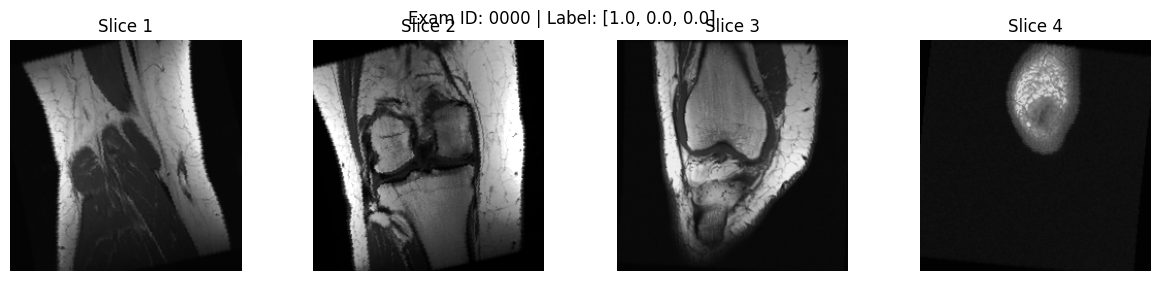

In [99]:
def denormalize_image(tensor_img):
    """
    Converts a normalized tensor image back to displayable format.
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor_img.cpu() * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

slice_stack, label, exam_id = train_dataset[0]

plt.figure(figsize=(15, 3))
for i in range(min(NUM_SLICES, 5)):
    plt.subplot(1, min(NUM_SLICES, 5), i + 1)
    plt.imshow(denormalize_image(slice_stack[i]))
    plt.title(f"Slice {i+1}")
    plt.axis("off")

plt.suptitle(f"Exam ID: {exam_id} | Label: {label.tolist()}")
plt.show()

In [100]:
def compute_pos_weights(dataset):
    """
    Computes positive class weights for BCEWithLogitsLoss.
    pos_weight = negatives / positives
    """
    all_labels = []

    for i in range(len(dataset)):
        _, label, _ = dataset[i]
        all_labels.append(label.numpy())

    all_labels = np.array(all_labels)
    positives = all_labels.sum(axis=0)
    negatives = len(all_labels) - positives

    pos_weight = negatives / (positives + 1e-8)
    return torch.tensor(pos_weight, dtype=torch.float32)

pos_weights = compute_pos_weights(train_dataset).to(DEVICE)
print("Positive class weights:", pos_weights)

Positive class weights: tensor([0.2377, 4.4327, 1.8463], device='mps:0')


In [101]:
class FocalBCEWithLogitsLoss(nn.Module):
    """
    Focal loss for multi-label binary classification.
    Reduces weight on easy negatives so the model focuses on hard examples.

    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)

    Args:
        gamma      : focusing parameter. 0 = standard BCE. 2 is the standard default.
        alpha      : scalar balance factor (like pos_weight in BCE, but simpler).
        pos_weight : per-class weight tensor, same as BCEWithLogitsLoss.
                     Use EITHER alpha OR pos_weight, not both.
        reduction  : 'mean' or 'sum'
    """
    def __init__(self, gamma=2.0, alpha=None, pos_weight=None, reduction='mean'):
        super().__init__()
        self.gamma     = gamma
        self.alpha     = alpha
        self.pos_weight = pos_weight   # shape: (num_classes,)
        self.reduction  = reduction

    def forward(self, logits, targets):
        # Standard BCE (no reduction yet) — shape: (B, C)
        bce = F.binary_cross_entropy_with_logits(
            logits, targets,
            pos_weight=self.pos_weight,
            reduction='none'
        )

        # p_t:  probability of the TRUE class
        probs = torch.sigmoid(logits)
        p_t   = probs * targets + (1 - probs) * (1 - targets)

        # Focal weight: down-weights easy (high confidence) examples
        focal_weight = (1 - p_t) ** self.gamma

        if self.alpha is not None:
            focal_weight = self.alpha * focal_weight

        loss = focal_weight * bce

        if self.reduction == 'mean':
            return loss.mean()
        return loss.sum()

In [102]:
class ViTMultiLabel(nn.Module):
    def __init__(self, model_name="vit_small_patch16_224", num_classes=3):
        super().__init__()

        # Load pretrained ViT model from timm
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=num_classes
        )

    def forward(self, x):
        """
        x shape: (B, S, 3, H, W)
        B = batch size
        S = number of slices per MRI

        We run ViT on each slice independently, then average slice logits.
        """
        B, S, C, H, W = x.shape

        # Merge batch and slice dimensions -> (B*S, C, H, W)
        x = x.view(B * S, C, H, W)

        # Run all slices through ViT
        logits = self.backbone(x)  # shape: (B*S, 3)

        # Restore slice dimension -> (B, S, 3)
        logits = logits.view(B, S, -1)

        # Average slice predictions over all selected slices
        logits = logits.mean(dim=1)

        return logits

In [103]:
model = ViTMultiLabel(num_classes=3).to(DEVICE)

# Freeze everything first
for param in model.backbone.parameters():
    param.requires_grad = False

# Unfreeze last 2 transformer blocks
for block in model.backbone.blocks[-2:]:
    for param in block.parameters():
        param.requires_grad = True

# Keep classification head trainable
for param in model.backbone.head.parameters():
    param.requires_grad = True

# ── Focal Loss (replaces BCEWithLogitsLoss) ──────────────────────────────────
# pos_weight still passed in so rare classes (ACL, meniscus) stay balanced.
# gamma=2 is the standard starting point; raise to 3 if easy negatives dominate.
criterion = FocalBCEWithLogitsLoss(
    gamma=2.0,
    pos_weight=pos_weights   # your existing pos_weights tensor
)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(model)

ViTMultiLabel(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
        

In [104]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())

print("Trainable params:", trainable_params)
print("Total params:", all_params)

Trainable params: 3550083
Total params: 21666819


In [105]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for images, labels, _ in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)   # shape: (B, S, 3, H, W)
        labels = labels.to(device)   # shape: (B, 3)

        optimizer.zero_grad()

        outputs = model(images)      # shape: (B, 3)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    epoch_loss = total_loss / len(loader.dataset)
    return epoch_loss

In [106]:
from sklearn import metrics


def evaluate_model(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0

    all_labels = []
    all_probs = []
    all_preds = []
    all_ids = []

    with torch.no_grad():
        for images, labels, exam_ids in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)
            preds = (probs >= threshold).float()

            total_loss += loss.item() * images.size(0)

            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_ids.extend(exam_ids)

    avg_loss = total_loss / len(loader.dataset)

    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)

    class_names = ["abnormal", "acl", "meniscus"]
    metrics = {}
    for i, class_name in enumerate(class_names):
        y_true = all_labels[:, i]
        y_prob = all_probs[:, i]
        y_pred = all_preds[:, i]

        intersection = np.logical_and(y_true, y_pred).sum()
        union        = np.logical_or(y_true, y_pred).sum()
        iou          = intersection / (union + 1e-8)

        metrics[class_name] = {
            "accuracy"  : accuracy_score(y_true, y_pred),
            "precision" : precision_score(y_true, y_pred, zero_division=0),
            "recall"    : recall_score(y_true, y_pred, zero_division=0),
            "f1"        : f1_score(y_true, y_pred, zero_division=0),
            "iou"       : iou,
            "auc_roc"   : roc_auc_score(y_true, y_prob)
        }

    return avg_loss, metrics, all_labels, all_probs, all_preds, all_ids

In [107]:
train_losses = []
valid_losses = []

best_val_loss = float("inf")
best_val_acc = 0  # NEW: track accuracy too

best_model_path = "best_vit_mrnet.pth"
last_model_path = "last_vit_mrnet.pth"

# TensorBoard (add this once above loop if not already)
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("runs/mrnet_vit")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

    valid_loss, valid_metrics, all_labels, all_probs, all_preds, all_ids = evaluate_model(
        model, valid_loader, criterion, DEVICE, threshold=THRESHOLD
    )

    scheduler.step()

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    # Extract overall accuracy (important for checkpointing + report)
    avg_val_acc = sum([m["accuracy"] for m in valid_metrics.values()]) / len(valid_metrics)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Avg Val Accuracy: {avg_val_acc:.4f}")

    #  TensorBoard logging
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", valid_loss, epoch)
    writer.add_scalar("Accuracy/val", avg_val_acc, epoch)

    for cls, cls_metrics in valid_metrics.items():
        print(f"\n{cls.upper()}")
        for metric_name, metric_value in cls_metrics.items():
            print(f"  {metric_name}: {metric_value:.4f}")

    #  Save LAST model (missing earlier)
    torch.save(model.state_dict(), last_model_path)

    #  Save BEST (by loss)
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"\nSaved BEST (loss) model to: {best_model_path}")

    # save best by accuracy 
    if avg_val_acc > best_val_acc:
        best_val_acc = avg_val_acc
        torch.save(model.state_dict(), "best_acc_model.pth")
        print("Saved BEST (accuracy) model")


Epoch 1/20


Train Loss: 0.2034
Valid Loss: 0.2405
Avg Val Accuracy: 0.5944

ABNORMAL
  accuracy: 0.7583
  precision: 0.8587
  recall: 0.8316
  f1: 0.8449
  iou: 0.7315
  auc_roc: 0.7621

ACL
  accuracy: 0.5417
  precision: 0.4946
  recall: 0.8519
  f1: 0.6259
  iou: 0.4554
  auc_roc: 0.6364

MENISCUS
  accuracy: 0.4833
  precision: 0.4545
  recall: 0.9615
  f1: 0.6173
  iou: 0.4464
  auc_roc: 0.5950

Saved BEST (loss) model to: best_vit_mrnet.pth
Saved BEST (accuracy) model

Epoch 2/20


Train Loss: 0.1838
Valid Loss: 0.3331
Avg Val Accuracy: 0.6056

ABNORMAL
  accuracy: 0.7417
  precision: 0.8721
  recall: 0.7895
  f1: 0.8287
  iou: 0.7075
  auc_roc: 0.7444

ACL
  accuracy: 0.5917
  precision: 0.6316
  recall: 0.2222
  f1: 0.3288
  iou: 0.1967
  auc_roc: 0.6779

MENISCUS
  accuracy: 0.4833
  precision: 0.4554
  recall: 0.9808
  f1: 0.6220
  iou: 0.4513
  auc_roc: 0.6360
Saved BEST (accuracy) model

Epoch 3/20


Train Loss: 0.1784
Valid Loss: 0.2108
Avg Val Accuracy: 0.6222

ABNORMAL
  accuracy: 0.8167
  precision: 0.8614
  recall: 0.9158
  f1: 0.8878
  iou: 0.7982
  auc_roc: 0.7465

ACL
  accuracy: 0.5000
  precision: 0.4737
  recall: 1.0000
  f1: 0.6429
  iou: 0.4737
  auc_roc: 0.6874

MENISCUS
  accuracy: 0.5500
  precision: 0.4894
  recall: 0.8846
  f1: 0.6301
  iou: 0.4600
  auc_roc: 0.6374

Saved BEST (loss) model to: best_vit_mrnet.pth
Saved BEST (accuracy) model

Epoch 4/20


Train Loss: 0.1729
Valid Loss: 0.2090
Avg Val Accuracy: 0.5917

ABNORMAL
  accuracy: 0.7250
  precision: 0.8875
  recall: 0.7474
  f1: 0.8114
  iou: 0.6827
  auc_roc: 0.7520

ACL
  accuracy: 0.5000
  precision: 0.4732
  recall: 0.9815
  f1: 0.6386
  iou: 0.4690
  auc_roc: 0.7006

MENISCUS
  accuracy: 0.5500
  precision: 0.4878
  recall: 0.7692
  f1: 0.5970
  iou: 0.4255
  auc_roc: 0.6524

Saved BEST (loss) model to: best_vit_mrnet.pth

Epoch 5/20


...

Train Loss: 0.1351
Valid Loss: 0.2350
Avg Val Accuracy: 0.7083

ABNORMAL
  accuracy: 0.8333
  precision: 0.8866
  recall: 0.9053
  f1: 0.8958
  iou: 0.8113
  auc_roc: 0.7983

ACL
  accuracy: 0.6750
  precision: 0.6119
  recall: 0.7593
  f1: 0.6777
  iou: 0.5125
  auc_roc: 0.7579

MENISCUS
  accuracy: 0.6167
  precision: 0.5484
  recall: 0.6538
  f1: 0.5965
  iou: 0.4250
  auc_roc: 0.6934

Epoch 17/20


Train Loss: 0.1365
Valid Loss: 0.2275
Avg Val Accuracy: 0.7056

ABNORMAL
  accuracy: 0.8333
  precision: 0.8788
  recall: 0.9158
  f1: 0.8969
  iou: 0.8131
  auc_roc: 0.7987

ACL
  accuracy: 0.6750
  precision: 0.6087
  recall: 0.7778
  f1: 0.6829
  iou: 0.5185
  auc_roc: 0.7573

MENISCUS
  accuracy: 0.6083
  precision: 0.5352
  recall: 0.7308
  f1: 0.6179
  iou: 0.4471
  auc_roc: 0.6951

Epoch 18/20


Train Loss: 0.1334
Valid Loss: 0.2353
Avg Val Accuracy: 0.7083

ABNORMAL
  accuracy: 0.8333
  precision: 0.8788
  recall: 0.9158
  f1: 0.8969
  iou: 0.8131
  auc_roc: 0.7987

ACL
  accuracy: 0.6833
  precision: 0.6176
  recall: 0.7778
  f1: 0.6885
  iou: 0.5250
  auc_roc: 0.7573

MENISCUS
  accuracy: 0.6083
  precision: 0.5397
  recall: 0.6538
  f1: 0.5913
  iou: 0.4198
  auc_roc: 0.6940

Epoch 19/20


Train Loss: 0.1338
Valid Loss: 0.2315
Avg Val Accuracy: 0.7083

ABNORMAL
  accuracy: 0.8333
  precision: 0.8788
  recall: 0.9158
  f1: 0.8969
  iou: 0.8131
  auc_roc: 0.7992

ACL
  accuracy: 0.6833
  precision: 0.6176
  recall: 0.7778
  f1: 0.6885
  iou: 0.5250
  auc_roc: 0.7584

MENISCUS
  accuracy: 0.6083
  precision: 0.5352
  recall: 0.7308
  f1: 0.6179
  iou: 0.4471
  auc_roc: 0.6951

Epoch 20/20


Train Loss: 0.1346
Valid Loss: 0.2319
Avg Val Accuracy: 0.7083

ABNORMAL
  accuracy: 0.8333
  precision: 0.8788
  recall: 0.9158
  f1: 0.8969
  iou: 0.8131
  auc_roc: 0.7996

ACL
  accuracy: 0.6833
  precision: 0.6176
  recall: 0.7778
  f1: 0.6885
  iou: 0.5250
  auc_roc: 0.7581

MENISCUS
  accuracy: 0.6083
  precision: 0.5352
  recall: 0.7308
  f1: 0.6179
  iou: 0.4471
  auc_roc: 0.6951


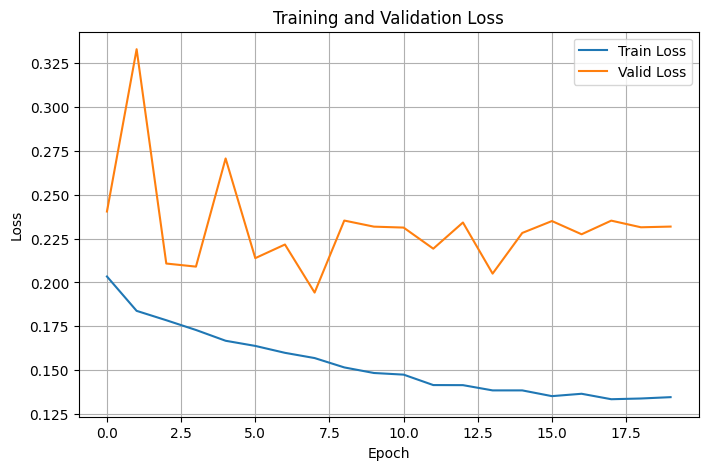

In [108]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [109]:
best_model = ViTMultiLabel(num_classes=3).to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
best_model.eval()

valid_loss, valid_metrics, all_labels, all_probs, all_preds, all_ids = evaluate_model(
    best_model, valid_loader, criterion, DEVICE, threshold=THRESHOLD
)

print("Final Validation Loss:", valid_loss)

for cls, cls_metrics in valid_metrics.items():
    print(f"\n{cls.upper()}")
    for metric_name, metric_value in cls_metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")

Final Validation Loss: 0.19422653540968896

ABNORMAL
accuracy: 0.8250
precision: 0.8936
recall: 0.8842
f1: 0.8889
iou: 0.8000
auc_roc: 0.7785

ACL
accuracy: 0.5083
precision: 0.4779
recall: 1.0000
f1: 0.6467
iou: 0.4779
auc_roc: 0.7444

MENISCUS
accuracy: 0.5833
precision: 0.5116
recall: 0.8462
f1: 0.6377
iou: 0.4681
auc_roc: 0.6770


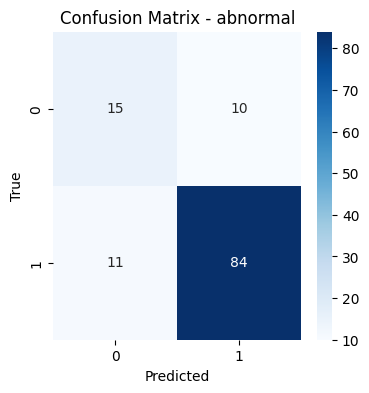

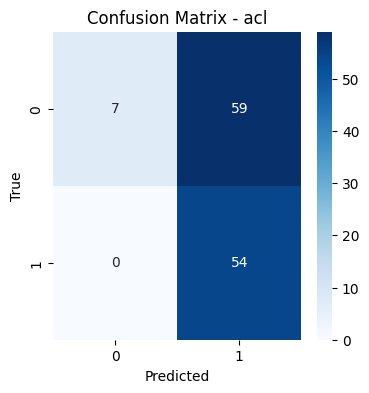

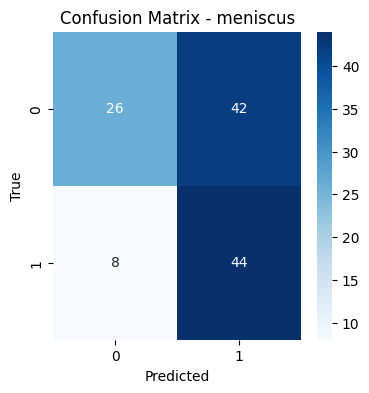

In [169]:
class_names = ["abnormal", "acl", "meniscus"]

for i, class_name in enumerate(class_names):
    cm = confusion_matrix(all_labels[:, i], all_preds[:, i])

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {class_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [170]:
results_df = pd.DataFrame({
    "exam_id": all_ids,

    "abnormal_true": all_labels[:, 0],
    "abnormal_prob": all_probs[:, 0],
    "abnormal_pred": all_preds[:, 0],

    "acl_true": all_labels[:, 1],
    "acl_prob": all_probs[:, 1],
    "acl_pred": all_preds[:, 1],

    "meniscus_true": all_labels[:, 2],
    "meniscus_prob": all_probs[:, 2],
    "meniscus_pred": all_preds[:, 2],
})

results_df.to_csv("validation_predictions.csv", index=False)
print("Saved validation_predictions.csv")

Saved validation_predictions.csv


In [171]:
def compute_attention_rollout(vit_backbone, x):
    """
    Computes attention rollout for a single input image tensor.

    Args:
        vit_backbone: timm ViT backbone
        x           : tensor of shape (1, 3, H, W)

    Returns:
        rollout mask of shape (grid_h, grid_w)
    """
    vit_backbone.eval()

    with torch.no_grad():
        # Patch embedding
        tokens = vit_backbone.patch_embed(x)  # (B, num_patches, embed_dim)

        B = tokens.shape[0]

        # Add cls token
        cls_token = vit_backbone.cls_token.expand(B, -1, -1)
        tokens = torch.cat((cls_token, tokens), dim=1)

        # Add positional embeddings
        tokens = tokens + vit_backbone.pos_embed
        tokens = vit_backbone.pos_drop(tokens)

        attention_matrices = []

        # Pass tokens through each transformer block
        for block in vit_backbone.blocks:
            norm_tokens = block.norm1(tokens)

            # Manually compute attention
            B_, N, C = norm_tokens.shape
            qkv = block.attn.qkv(norm_tokens)
            qkv = qkv.reshape(B_, N, 3, block.attn.num_heads, C // block.attn.num_heads)
            qkv = qkv.permute(2, 0, 3, 1, 4)

            q, k, v = qkv[0], qkv[1], qkv[2]

            attn = (q @ k.transpose(-2, -1)) * block.attn.scale
            attn = attn.softmax(dim=-1)

            # Average over attention heads
            attn = attn.mean(dim=1)  # shape: (B, N, N)
            attention_matrices.append(attn)

            # Continue normal block forward
            tokens = block(tokens)

        # Attention rollout
        eye = torch.eye(attention_matrices[0].size(-1), device=x.device).unsqueeze(0)

        joint_attention = eye.repeat(B, 1, 1)
        for attn in attention_matrices:
            attn = attn + eye
            attn = attn / attn.sum(dim=-1, keepdim=True)
            joint_attention = attn @ joint_attention

        # Take cls token attention to patch tokens
        mask = joint_attention[:, 0, 1:]  # (B, num_patches)

        num_patches = mask.shape[-1]
        grid_size = int(math.sqrt(num_patches))

        mask = mask.reshape(B, grid_size, grid_size)
        return mask[0].cpu().numpy()

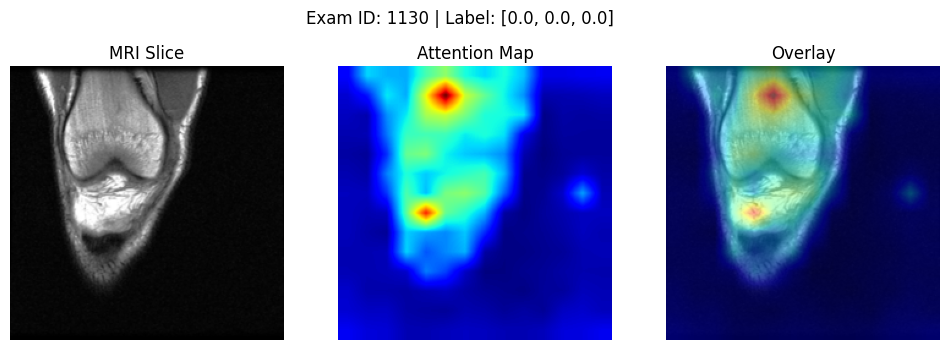

In [172]:
def show_attention_for_exam(dataset, model, exam_index=0):
    """
    Visualizes attention map for the middle selected slice of one MRI exam.
    """
    slice_stack, label, exam_id = dataset[exam_index]

    # Choose middle sampled slice for visualisation
    chosen_slice_index = len(slice_stack) // 2
    img_tensor = slice_stack[chosen_slice_index].unsqueeze(0).to(DEVICE)

    # Get rollout attention map
    attention_map = compute_attention_rollout(model.backbone, img_tensor)

    # Resize attention map to image size
    attention_map = torch.tensor(attention_map).unsqueeze(0).unsqueeze(0)
    attention_map = F.interpolate(
        attention_map,
        size=(IMG_SIZE, IMG_SIZE),
        mode="bilinear",
        align_corners=False
    ).squeeze().numpy()

    # Recover image for plotting
    original_img = denormalize_image(slice_stack[chosen_slice_index])

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("MRI Slice")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(attention_map, cmap="jet")
    plt.title("Attention Map")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(original_img)
    plt.imshow(attention_map, cmap="jet", alpha=0.45)
    plt.title("Overlay")
    plt.axis("off")

    plt.suptitle(f"Exam ID: {exam_id} | Label: {label.tolist()}")
    plt.show()

show_attention_for_exam(valid_dataset, best_model, exam_index=0)

In [173]:
class OODImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_paths = sorted(
            glob.glob(os.path.join(image_dir, "*.png")) +
            glob.glob(os.path.join(image_dir, "*.jpg")) +
            glob.glob(os.path.join(image_dir, "*.jpeg")) +
            glob.glob(os.path.join(image_dir, "*.JPG")) +
            glob.glob(os.path.join(image_dir, "*.PNG"))
        )
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, os.path.basename(image_path)

In [174]:
def run_ood_inference(model, image_dir, transform, device, threshold=0.5):
    """
    Runs inference on external OOD images.
    """
    model.eval()

    ood_dataset = OODImageDataset(image_dir=image_dir, transform=transform)

    results = []
    class_names = ["abnormal", "acl", "meniscus"]

    with torch.no_grad():
        for image, filename in ood_dataset:
            # shape: (3, H, W) -> convert to fake multi-slice input of shape (1, 1, 3, H, W)
            image = image.unsqueeze(0).unsqueeze(0).to(device)

            outputs = model(image)
            probs = torch.sigmoid(outputs).squeeze(0).cpu().numpy()
            preds = (probs >= threshold).astype(int)

            result = {"filename": filename}
            for i, class_name in enumerate(class_names):
                result[f"{class_name}_prob"] = float(probs[i])
                result[f"{class_name}_pred"] = int(preds[i])

            results.append(result)

    return pd.DataFrame(results)

In [175]:
ood_results_df = run_ood_inference(
    model=best_model,
    image_dir=OOD_ROOT,
    transform=valid_transform,
    device=DEVICE,
    threshold=THRESHOLD
)

ood_results_df

,filename,abnormal_prob,abnormal_pred,acl_prob,acl_pred,meniscus_prob,meniscus_pred
0,Acl_sag.jpg,0.691087,1,0.831897,1,0.577177,1
1,Acl_sag2.jpeg,0.431840,0,0.889357,1,0.344046,0
2,Meni_sag_2.jpg,0.863016,1,0.537242,1,0.760933,1
3,meni_coronal_1.png,0.378547,0,0.823285,1,0.516812,1
4,meni_sag_1.jpg,0.662358,1,0.366044,0,0.763893,1
5,normal_coronal.jpeg,0.424482,0,0.472532,1,0.258649,0
6,normal_sag_2.jpeg,0.535877,1,0.822816,1,0.523281,1


In [176]:
ood_results_df.to_csv("ood_predictions.csv", index=False)
print("Saved ood_predictions.csv")

Saved ood_predictions.csv


In [177]:
import os
import glob
import numpy as np
import pandas as pd
from PIL import Image
import torch

OOD_ROOT = "/Users/yaseenahmed/Documents/EEEM068-MRNet-ViT/OOD_images"

# stricter OOD thresholds
abnormal_threshold = 0.60
acl_threshold = 0.80
meniscus_threshold = 0.75

results = []
best_model.eval()

with torch.no_grad():
    image_paths = sorted(
        glob.glob(os.path.join(OOD_ROOT, "*.jpg")) +
        glob.glob(os.path.join(OOD_ROOT, "*.jpeg")) +
        glob.glob(os.path.join(OOD_ROOT, "*.png"))
    )

    for img_path in image_paths:
        # load as grayscale first, then normalize, then convert to RGB
        img = Image.open(img_path).convert("L")
        img = np.array(img)
        img = ((img - img.min()) / (img.max() - img.min() + 1e-8) * 255).astype(np.uint8)
        img = Image.fromarray(img).convert("RGB")

        img = valid_transform(img)

        # shape -> (1,1,3,H,W)
        img = img.unsqueeze(0).unsqueeze(0).to(DEVICE)

        output = best_model(img)
        probs = torch.sigmoid(output).cpu().numpy()[0]

        abnormal_prob, acl_prob, meniscus_prob = probs

        abnormal_pred = int(abnormal_prob >= abnormal_threshold)
        acl_pred = int(acl_prob >= acl_threshold)
        meniscus_pred = int(meniscus_prob >= meniscus_threshold)

        results.append({
            "filename": os.path.basename(img_path),
            "abnormal_prob": float(abnormal_prob),
            "abnormal_pred": abnormal_pred,
            "acl_prob": float(acl_prob),
            "acl_pred": acl_pred,
            "meniscus_prob": float(meniscus_prob),
            "meniscus_pred": meniscus_pred
        })

ood_df = pd.DataFrame(results)
ood_df

,filename,abnormal_prob,abnormal_pred,acl_prob,acl_pred,meniscus_prob,meniscus_pred
0,Acl_sag.jpg,0.699867,1,0.835164,1,0.581126,0
1,Acl_sag2.jpeg,0.418269,0,0.890739,1,0.339131,0
2,Meni_sag_2.jpg,0.849668,1,0.542231,0,0.800465,1
3,meni_coronal_1.png,0.390341,0,0.820547,1,0.520896,0
4,meni_sag_1.jpg,0.659573,1,0.361678,0,0.756212,1
5,normal_coronal.jpeg,0.438885,0,0.470076,0,0.289333,0
6,normal_sag_2.jpeg,0.535755,0,0.828613,1,0.520282,0


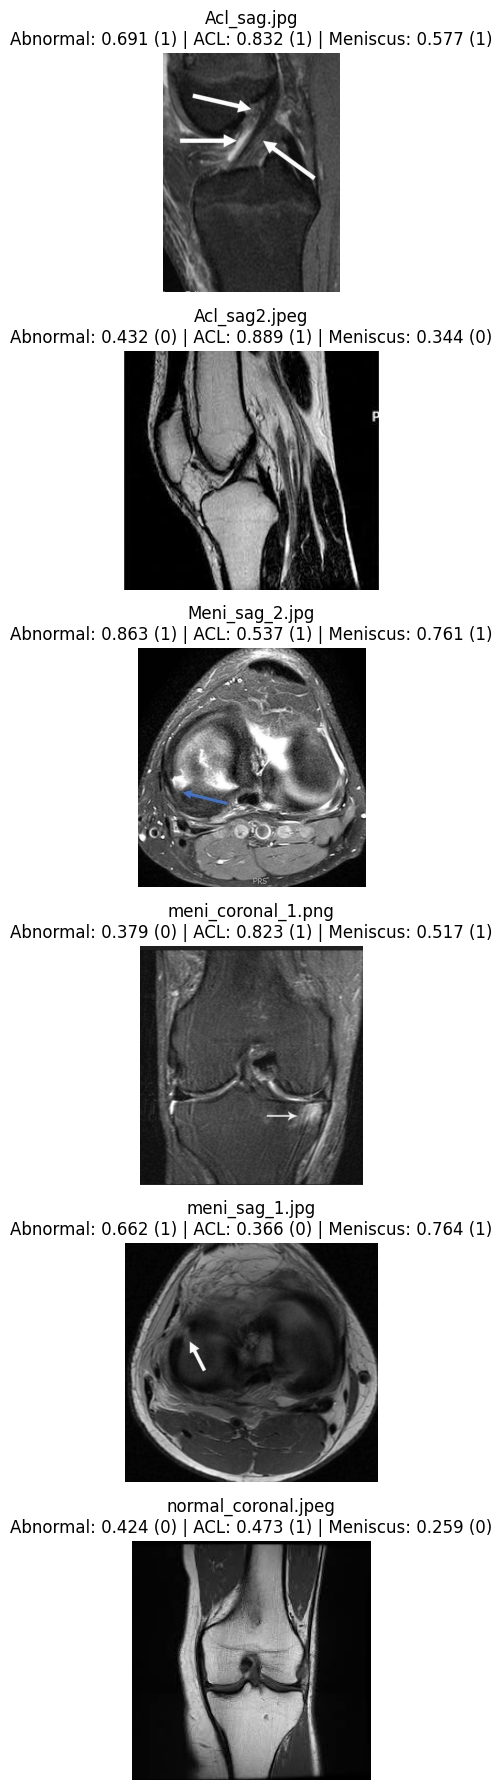

In [178]:
def show_ood_predictions(ood_root, results_df, max_images=6):
    image_files = results_df["filename"].tolist()[:max_images]

    plt.figure(figsize=(15, 3 * max_images))

    for i, filename in enumerate(image_files):
        image_path = os.path.join(ood_root, filename)
        img = Image.open(image_path).convert("RGB")

        row = results_df[results_df["filename"] == filename].iloc[0]

        title = (
            f"{filename}\n"
            f"Abnormal: {row['abnormal_prob']:.3f} ({row['abnormal_pred']}) | "
            f"ACL: {row['acl_prob']:.3f} ({row['acl_pred']}) | "
            f"Meniscus: {row['meniscus_prob']:.3f} ({row['meniscus_pred']})"
        )

        plt.subplot(max_images, 1, i + 1)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_ood_predictions(OOD_ROOT, ood_results_df, max_images=min(6, len(ood_results_df)))

In [179]:
# Validation metrics table
metrics_rows = []
for cls, cls_metrics in valid_metrics.items():
    row = {"class": cls}
    row.update(cls_metrics)
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,class,accuracy,precision,recall,f1,iou,auc_roc
0,abnormal,0.825000,0.893617,0.884211,0.888889,0.800000,0.778526
1,acl,0.508333,0.477876,1.000000,0.646707,0.477876,0.744388
2,meniscus,0.583333,0.511628,0.846154,0.637681,0.468085,0.677036


In [180]:
metrics_df.to_csv("validation_metrics.csv", index=False)
print("Saved validation_metrics.csv")

Saved validation_metrics.csv


In [181]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image

def show_ood_attention_maps(ood_root, model, transform, device, threshold=0.5, max_images=6):
    """
    Shows original OOD image, attention map, and overlay.
    Works with CLS-token ViT model where model.backbone is the timm ViT.
    """
    model.eval()

    image_paths = sorted(
        glob.glob(os.path.join(ood_root, "*.jpg")) +
        glob.glob(os.path.join(ood_root, "*.jpeg")) +
        glob.glob(os.path.join(ood_root, "*.png"))
    )[:max_images]

    class_names = ["abnormal", "acl", "meniscus"]

    for img_path in image_paths:
        # Load original image
        pil_img = Image.open(img_path).convert("RGB")
        original_img = np.array(pil_img)

        # Transform for model
        img_tensor = transform(pil_img).unsqueeze(0).to(device)  # (1, 3, H, W)

        # Prediction
        with torch.no_grad():
            # Make shape compatible with your volume-based model: (1,1,3,H,W)
            output = model(img_tensor.unsqueeze(1))
            probs = torch.sigmoid(output).squeeze(0).cpu().numpy()
            preds = (probs >= threshold).astype(int)

        # Attention rollout from backbone
        attention_map = compute_attention_rollout(model.backbone, img_tensor)

        # Resize attention map to image size
        attention_map = torch.tensor(attention_map).unsqueeze(0).unsqueeze(0).float()
        attention_map = F.interpolate(
            attention_map,
            size=(original_img.shape[0], original_img.shape[1]),
            mode="bilinear",
            align_corners=False
        ).squeeze().numpy()

        # Plot
        pred_text = " | ".join([
            f"{class_names[i]}: {probs[i]:.2f} ({preds[i]})" for i in range(3)
        ])

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(original_img)
        plt.title(f"Original\n{os.path.basename(img_path)}")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(attention_map, cmap="jet")
        plt.title("Attention Map")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(original_img)
        plt.imshow(attention_map, cmap="jet", alpha=0.45)
        plt.title(f"Overlay\n{pred_text}")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

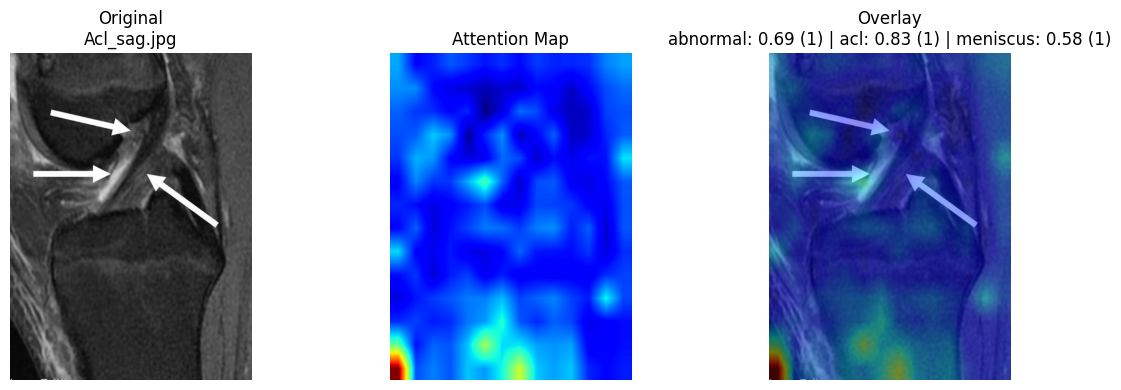

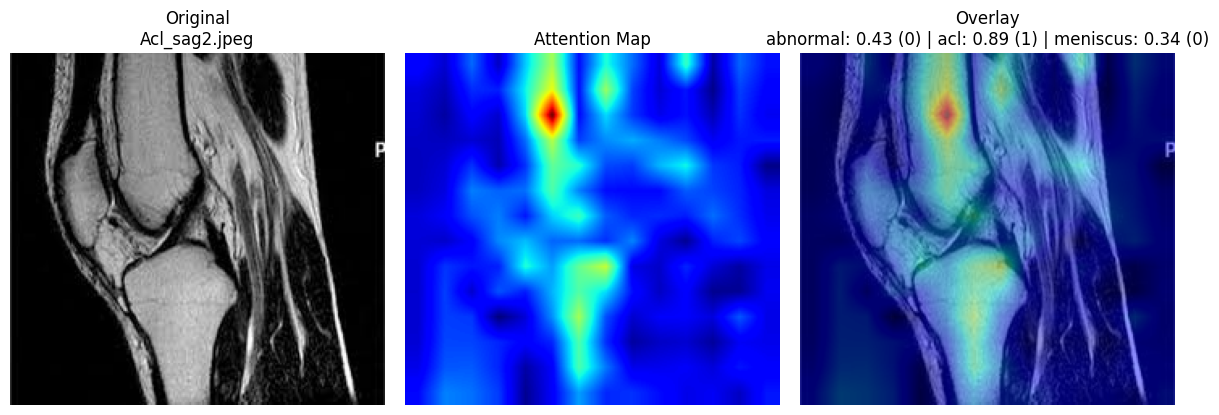

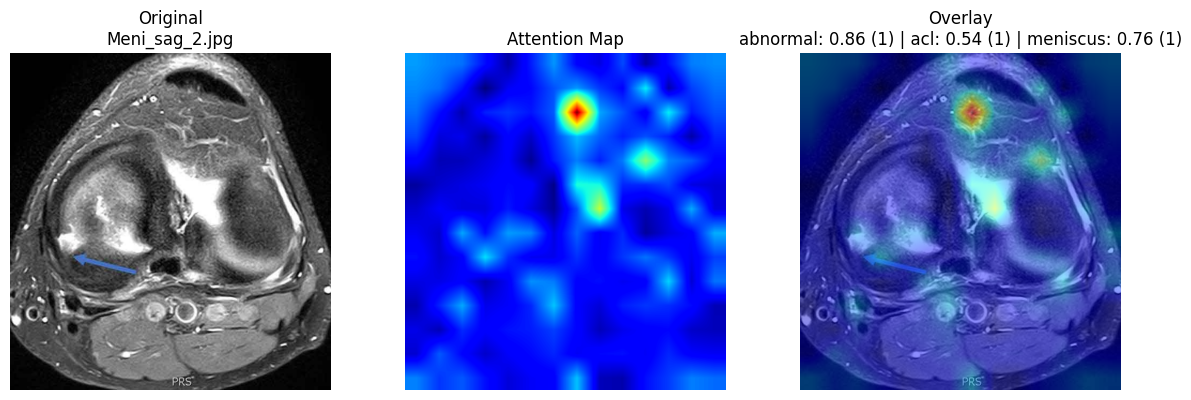

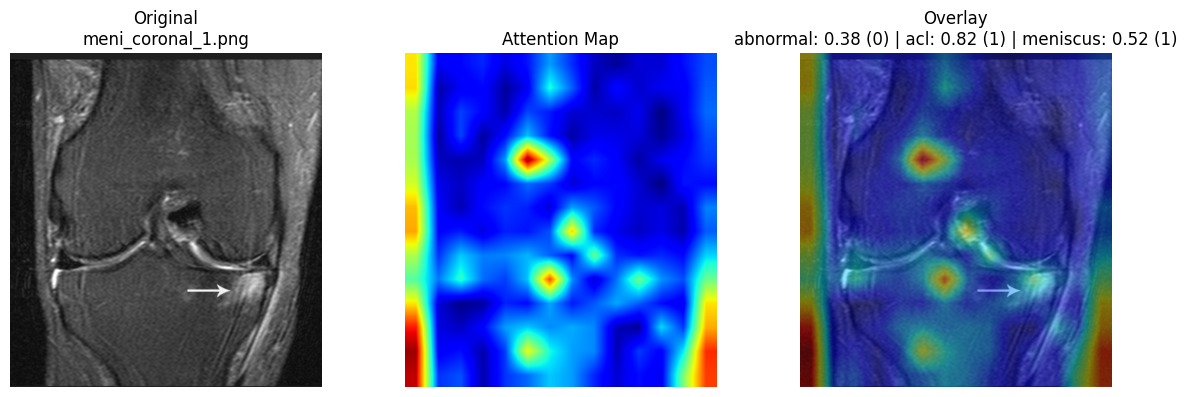

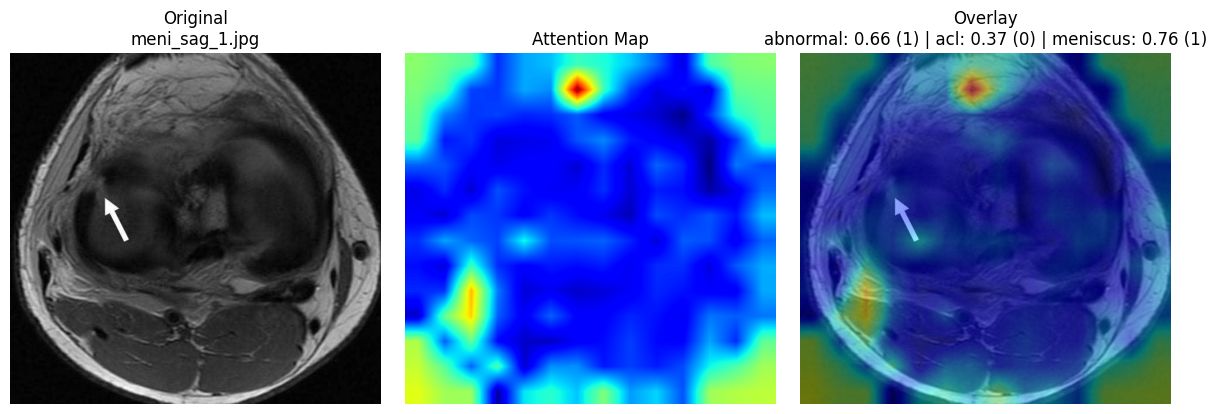

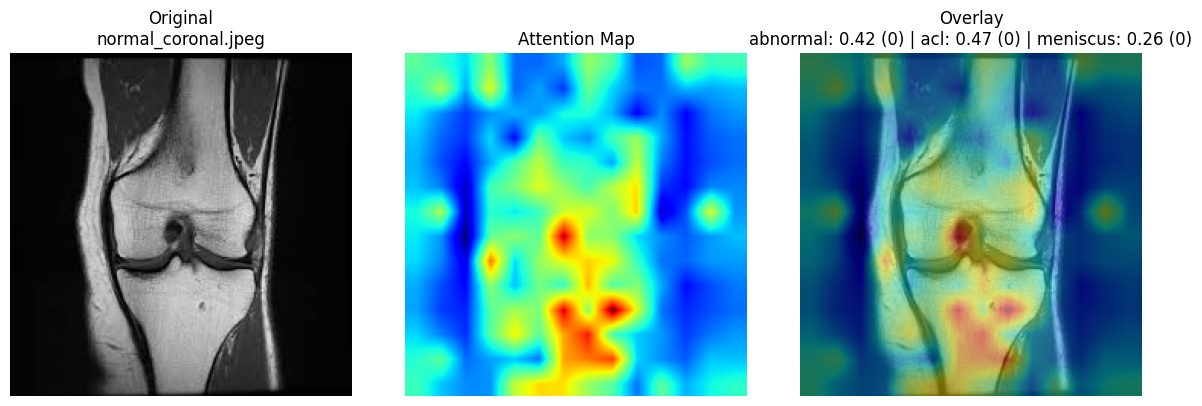

In [182]:
OOD_ROOT = "/Users/yaseenahmed/Documents/EEEM068-MRNet-ViT/OOD_images"

show_ood_attention_maps(
    ood_root=OOD_ROOT,
    model=best_model,
    transform=valid_transform,
    device=DEVICE,
    threshold=0.5,
    max_images=6
)